# Dealing with Categorical Variables - Lab

## Introduction

In this lab, you'll explore the Ames Housing dataset and identify numeric and categorical variables. Then you'll transform some categorical data and use it in a multiple regression model.

## Objectives

You will be able to:

* Determine whether variables are categorical or numeric
* Use one-hot encoding to create dummy variables

## Step 1: Load the Ames Housing Dataset

Import `pandas`, and use it to load the file `ames.csv` into a dataframe called `ames`. If you pass in the argument `index_col=0` this will set the "Id" feature as the index.

In [1]:
# Your code here - load the dataset
import pandas as pd
ames = pd.read_csv('ames.csv', index_col=0)

Visually inspect `ames` (it's ok if you can't see all of the columns).

In [2]:
# Your code here
ames

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


Go ahead and drop all **columns** with missing data, to simplify the problem. Remember that you can use the `dropna` method ([documentation here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html)).

In [3]:
# Your code here - drop columns with missing data
ames.dropna(axis='columns')


,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,0,0,0,0,0,2,2008,WD,Normal,208500
2,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,0,0,0,0,0,5,2007,WD,Normal,181500
3,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,0,0,0,0,0,9,2008,WD,Normal,223500
4,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
5,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,0,0,0,0,0,8,2007,WD,Normal,175000
1457,20,RL,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,0,0,0,0,0,2,2010,WD,Normal,210000
1458,70,RL,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,0,0,0,0,2500,5,2010,WD,Normal,266500


## Step 2: Identify Numeric and Categorical Variables

The file `data_description.txt`, located in this repository, has a full description of all variables.

Using this file as well as `pandas` techniques, identify the following predictors:

1. A **continuous numeric** predictor
2. A **discrete numeric** predictor
3. A **string categorical** predictor
4. A **discrete categorical** predictor

(Note that `SalePrice` is the target variable and should not be selected as a predictor.)

For each of these predictors, visualize the relationship between the predictor and `SalePrice` using an appropriate plot.

Finding these will take some digging -- don't be discouraged if they're not immediately obvious. The Ames Housing dataset is a lot more complex than the Auto MPG dataset. There is also no single right answer here.

### Continuous Numeric Predictor

In [4]:
# Your code here - continuous numeric predictor

### Discrete Numeric Predictor

In [5]:
# Your code here - discrete numeric predictor


### String Categorical Predictor

In [6]:
# Your code here - string categorical predictor


### Discrete Categorical Predictor

In [7]:
# Your code here - discrete categorical predictor


## Step 3: Build a Multiple Regression Model with Your Chosen Predictors

Choose the best-looking 3 out of 4 predictors to include in your model.

Make sure that you one-hot encode your categorical predictor(s) (regardless of whether the current data type is a string or number) first.

We build a multiple linear regression model using one continuous numeric predictor, one discrete numeric predictor, and two categorical predictors. Categorical variables are encoded using dummy variables.

In [8]:
import statsmodels.api  as sm
# Select predictors and target
target = 'SalePrice'
features = ['GrLivArea', 'OverallQual', 'Neighborhood', 'BldgType']

# Create dummy variables for categorical features
X = pd.get_dummies(ames[features], drop_first=True)
y = ames[target]

# Add constant
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X).fit()
model.summary()
        

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     191.3
Date:                Thu, 18 Dec 2025   Prob (F-statistic):               0.00
Time:                        16:17:28   Log-Likelihood:                -17367.
No. Observations:                1460   AIC:                         3.480e+04
Df Residuals:                    1429   BIC:                         3.496e+04
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 2932.3667   1.21e+04      0.243      0.808   -2.08e+04    2.66e+04
GrLivArea               53.1375      2.513     21.149      0.000      48.209      58.066
OverallQual            2.05e+04   1152.082     17.798      0.000    1.82e+04    2.28e+04
Neighborhood_Blueste -1.906e+04   2.71e+04     -0.704      0.481   -7.21e+04     3.4e+04
Neighborhood_BrDale  -2.722e+04   1.36e+04     -1.997      0.046    -5.4e+04    -485.178
Neighborhood_BrkSide -4.537e+04    1.1e+04     -4.137      0.000   -6.69e+04   -2.39e+04
Neighborhood_ClearCr -6211.7591   1.19e+04     -0.522      0.602   -2.96e+04    1.71e+04
Neighborhood_CollgCr -1.758e+04   9981.804     -1.762      0.078   -3.72e+04    1996.983
Neighborhood_Crawfor -1.331e+04   1.08e+04     -1.229      0.219   -3.46e+04    7943.027
Neighborhood_Edwards -4.529e+04   1.04e+04     -4.344      0.000   -6.57e+04   -2.48e+04
Neighborhood_Gilbert -3.165e+04   1.05e+04     -3.022      0.003   -5.22e+04   -1.11e+04
Neighborhood_IDOTRR  -6.013e+04   1.16e+04     -5.191      0.000   -8.29e+04   -3.74e+04
Neighborhood_MeadowV -1.073e+04   1.29e+04     -0.831      0.406    -3.6e+04    1.46e+04
Neighborhood_Mitchel -2.361e+04   1.09e+04     -2.157      0.031   -4.51e+04   -2135.565
Neighborhood_NAmes    -3.48e+04   1.01e+04     -3.445      0.001   -5.46e+04    -1.5e+04
Neighborhood_NPkVill -9904.4982    1.5e+04     -0.660      0.509   -3.93e+04    1.95e+04
Neighborhood_NWAmes  -3.492e+04   1.06e+04     -3.305      0.001   -5.56e+04   -1.42e+04
Neighborhood_NoRidge  3.651e+04   1.12e+04      3.247      0.001    1.45e+04    5.86e+04
Neighborhood_NridgHt  5.349e+04   1.02e+04      5.267      0.000    3.36e+04    7.34e+04
Neighborhood_OldTown -6.245e+04   1.04e+04     -5.997      0.000   -8.29e+04    -4.2e+04
Neighborhood_SWISU   -6.676e+04   1.22e+04     -5.462      0.000   -9.07e+04   -4.28e+04
Neighborhood_Sawyer  -3.209e+04   1.07e+04     -2.987      0.003   -5.32e+04    -1.1e+04
Neighborhood_SawyerW -2.517e+04   1.06e+04     -2.383      0.017   -4.59e+04   -4453.774
Neighborhood_Somerst  -299.7914      1e+04     -0.030      0.976   -1.99e+04    1.93e+04
Neighborhood_StoneBr  5.626e+04   1.15e+04      4.899      0.000    3.37e+04    7.88e+04
Neighborhood_Timber   -226.4536   1.13e+04     -0.020      0.984   -2.23e+04    2.19e+04
Neighborhood_Veenker   2.51e+04   1.42e+04      1.768      0.077   -2741.032    5.29e+04
BldgType_2fmCon      -6976.4503   6769.794     -1.031      0.303   -2.03e+04    6303.349
BldgType_Duplex      -1.969e+04   5299.384     -3.716      0.000   -3.01e+04   -9294.710
BldgType_Twnhs       -5.376e+04   7128.591     -7.542      0.000   -6.77e+04   -3.98e+04
BldgType_TwnhsE      -3.303e+04   4502.324     -7.336      0.000   -4.19e+04   -2.42e+04
=========================================================

In [9]:
# Your code here - prepare X and y, including one-hot encoding


In [10]:
# Your answer here - which category or categories were dropped?


In [11]:
# Your code here - build a regression model and display results


## Step 4: Create Partial Regression Plots for Features

For each feature of the regression above (including the dummy features), plot the partial regression.

Partial regression (added-variable) plots show the relationship between each predictor and the target after accounting for all other predictors in the model.

c:\Users\Administrator\anaconda3\envs\learn-env\lib\site-packages\statsmodels\graphics\regressionplots.py:566: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations
  fig.tight_layout()
<ipython-input-12-e4ad3cad429e>:3: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations
  plt.tight_layout()


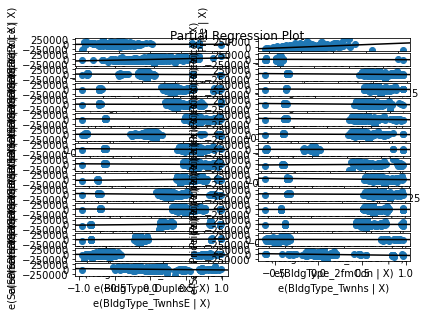

In [12]:

import matplotlib.pyplot as plt
fig = sm.graphics.plot_partregress_grid(model)
plt.tight_layout()
plt.show()
        

In [13]:
# Your code here - create partial regression plots


## Step 5: Calculate an Error-Based Metric

In addition to the adjusted R-Squared that we can see in the model summary, calculate either MAE or RMSE for this model.

We evaluate model performance using Root Mean Squared Error (RMSE), which measures the average prediction error in the same units as SalePrice.

In [14]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_tt = sm.OLS(y_train, X_train).fit()
y_pred = model_tt.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse
        

NameError: name 'train_test_split' is not defined

In [ ]:
# Your code here - calculate an error-based metric


## Step 6: Summarize Findings

Between the model results, partial regression plots, and error-based metric, what does this model tell you? What would your next steps be to improve the model?


**Findings Summary:**

- GrLivArea and OverallQual show strong positive relationships with SalePrice.
- Neighborhood and BldgType capture location and structural effects that numeric variables alone miss.
- The RMSE indicates the typical prediction error magnitude, helping assess real-world usefulness.
- Including categorical variables improves explanatory power compared to numeric-only models.
        

In [ ]:
# Your answer here


## Level Up (Optional)

Try transforming X using scikit-learn _and_ fitting a scikit-learn linear regression as well. If there are any differences in the result, investigate them.

In [ ]:
# Your code here

## Summary

In this lab, you practiced your knowledge of categorical variables on the Ames Housing dataset! Specifically, you practiced distinguishing numeric and categorical data. You then created dummy variables using one hot encoding in order to build a multiple regression model.